# Discrete Voter Model Phase Space Dynamics

This notebook simulates the discrete voter model on an ER network and visualizes trajectories in the ρ-m plane.

- ρ = active-link density (fraction of active edges)
- m = magnetization (ranges from -1 to +1)
- r = 0 (no stochastic resetting for now)

## Section 1: Import Required Libraries

In [7]:
using Random
using Plots
using Statistics
using Printf

gr()  # Use GR backend for faster plotting

# Load VoterResetting module
candidates = [abspath(pwd()), abspath(joinpath(pwd(), "..")), abspath(joinpath(pwd(), "..", ".."))]
project_root = nothing
for p in candidates
    if isfile(joinpath(p, "src", "VoterResetting.jl"))
        global project_root = p
        break
    end
end
project_root === nothing && error("Could not locate project root containing src/VoterResetting.jl from pwd=$(pwd())")

include(joinpath(project_root, "src", "VoterResetting.jl"))
const VR = VoterResetting
println("Loaded VoterResetting from: $(project_root)")

Loaded VoterResetting from: c:\Users\gerar\Desktop\Escola\Universitat\Master\TFM\voter-model-stochastic-resetting\


## Section 2: Define the Discrete Voter Model Dynamics

In the discrete voter model on all-to-all network:
- Each time step: pick two agents uniformly at random
- The second agent adopts the opinion of the first (or vice versa with equal probability)
- We track the state as `nstates[1]` = number of agents in state 1

## Section 3: Initialize System Parameters

In [8]:
# Graph and system parameters
N = 500  # System size
μ = 15.0  # Mean degree (adjust this to change network density)
r = 0.0 # Reset rate (0 = no resetting for now)
nsteps = 5000  # Number of discrete time steps to simulate

# Create Erdős-Rényi graph with mean degree μ
using Graphs
G = erdos_renyi(N, μ / (N - 1))
actual_mean_degree = 2 * ne(G) / N

# Initial condition: start at m = 0
m_init = 0.0
n1_init = Int(N ÷ 2)

# Initial +1 node fraction used to construct m0
frac_plus_init = n1_init / N

println("Graph Parameters:")
println("  N = $N")
println("  Target μ = $μ")
println("  Actual μ = $(round(actual_mean_degree, digits=2))")
println("  Edges = $(ne(G))")
println()
println("Dynamics Parameters:")
println("  r = $r (no resetting)")
println("  nsteps = $nsteps")
println()
println("Initial Condition:")
println("  n1 = $n1_init (fraction +1 nodes = $(round(frac_plus_init, digits=3)), m = $(round(m_init, digits=3)))")

Graph Parameters:
  N = 500
  Target μ = 15.0
  Actual μ = 14.62
  Edges = 3654

Dynamics Parameters:
  r = 0.0 (no resetting)
  nsteps = 5000

Initial Condition:
  n1 = 250 (fraction +1 nodes = 0.5, m = 0.0)


## Section 4: Run Simulation Loop

Track ρ_active (active-link density) and m (magnetization) at each time step.

In [9]:
# Run one trajectory using the API function for the complex network phase space
println("Running simulation on ER graph...")
t_start = time()

phase_space = VR.simulate_phase_space_discrete_complex(
    G, n1_init, r, nsteps;
    seed = 42,
    reset = VR.delta_reset(m_init)
)

trajectory_rho = phase_space.rho
trajectory_m = phase_space.m
trajectory_step = collect(0:nsteps)

elapsed = time() - t_start
println("Simulation complete in $(round(elapsed, digits=3)) s")
println("Trajectory length: $(length(trajectory_m)) steps")
println("Final state: ρ_active = $(round(trajectory_rho[end], digits=4)), m = $(round(trajectory_m[end], digits=4))")

Running simulation on ER graph...
Simulation complete in 0.362 s
Trajectory length: 5001 steps
Final state: ρ_active = 0.4496, m = 0.112


In [10]:
# Compute theoretical pair-approximation curve from the paper
# For r = 0, the stationary active-link density is
#   rho(m) = ((mu - 2) / (2 * (mu - 1))) * (1 - m^2)
# using the mean degree of the ER graph.

theory_m_grid = collect(range(-1.0, 1.0, length = 200))
theory_mu = actual_mean_degree
theory_rho_curve = ((theory_mu - 2) / (2 * (theory_mu - 1))) .* (1 .- theory_m_grid .^ 2)

println("Computed analytical pair-approximation curve")
println("  mu = $(round(theory_mu, digits=3))")
println("  theory points = $(length(theory_m_grid))")
println("  rho(m=0) = $(round(theory_rho_curve[argmin(abs.(theory_m_grid .- 0.0))], digits=6))")


Computed analytical pair-approximation curve
  mu = 14.616
  theory points = 200
  rho(m=0) = 0.463267


## Section 5: Compute Theoretical Pair-Approximation Curve

Compute the analytical active-link density curve from the pair-approximation formula in the paper. For `r = 0`, the stationary branch is

\[
\rho(m) = \frac{\mu - 2}{2(\mu - 1)}(1 - m^2)
\]


## Section 6: Plot Trajectory in ρ_active-m Plane

Create a 2D visualization of the system's evolution in phase space, with arrows showing the direction of time.


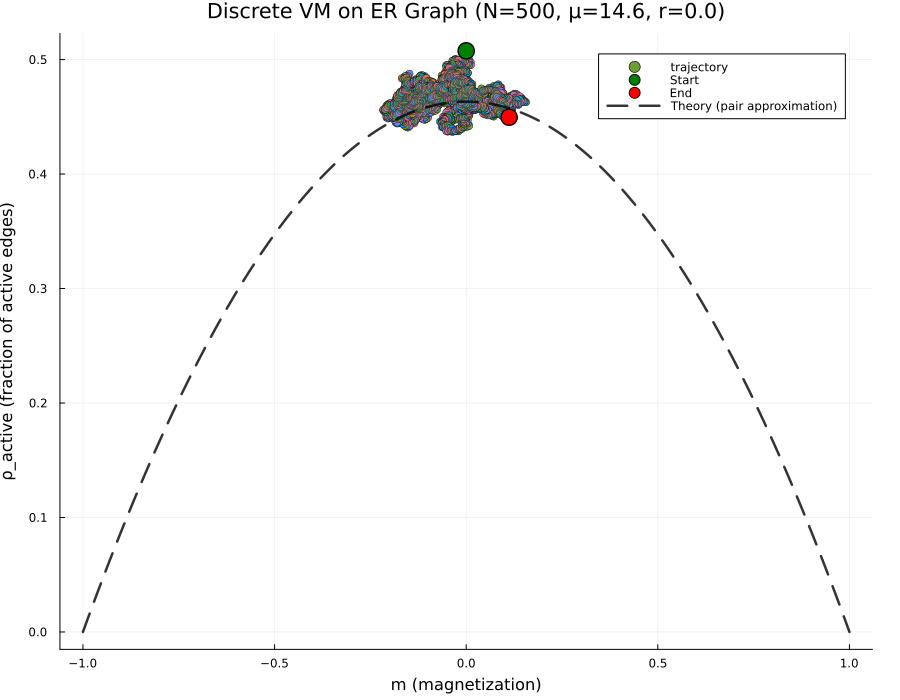

In [11]:
# Main trajectory plot with time-colored points and theoretical curve overlay
p_traj = plot(
    xlabel = "m (magnetization)",
    ylabel = "ρ_active (fraction of active edges)",
    title = "Discrete VM on ER Graph (N=$N, μ=$(round(actual_mean_degree, digits=1)), r=$r)",
    legend = :topright,
    size = (900, 700),
    linewidth = 2.5,
)

scatter!(p_traj, trajectory_m, trajectory_rho,
    color = trajectory_step,
    cgrad = :viridis,
    markersize = 4,
    markerstrokewidth = 0.3,
    label = "trajectory",
    colorbar_title = "Step",
)

plot!(p_traj, trajectory_m, trajectory_rho,
    color = :gray,
    alpha = 0.35,
    linewidth = 1.5,
    label = "",
)

scatter!(p_traj, [trajectory_m[1]], [trajectory_rho[1]],
    color = :green,
    markersize = 9,
    markerstroke = 2,
    label = "Start",
)

scatter!(p_traj, [trajectory_m[end]], [trajectory_rho[end]],
    color = :red,
    markersize = 9,
    markerstroke = 2,
    label = "End",
)

# Overlay theoretical curve
plot!(p_traj, theory_m_grid, theory_rho_curve,
    color = :black,
    linestyle = :dash,
    linewidth = 2.5,
    alpha = 0.8,
    label = "Theory (pair approximation)",
)

p_traj


## Section 7: Visualize Multiple Trajectories

Run multiple simulations with different initial magnetizations m₀ and compare trajectories in the ρ_active-m plane.


Running 5 trajectories with different initial conditions...
Multi-trajectory simulation complete in 0.04 s


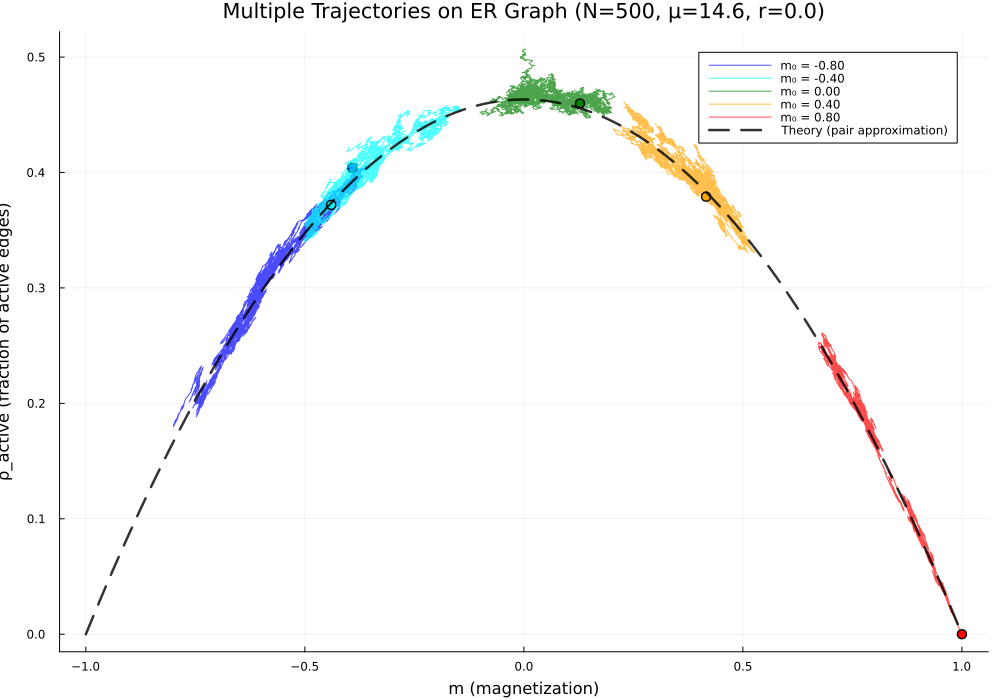

In [12]:
# Run multiple trajectories on the same ER graph
initial_ms = [-0.8, -0.4, 0.0, 0.4, 0.8]
colors = [:blue, :cyan, :green, :orange, :red]

p_multi = plot(
    xlabel = "m (magnetization)",
    ylabel = "ρ_active (fraction of active edges)",
    title = "Multiple Trajectories on ER Graph (N=$N, μ=$(round(actual_mean_degree, digits=1)), r=$r)",
    legend = :topright,
    size = (1000, 700),
    linewidth = 2.0,
)

println("Running $(length(initial_ms)) trajectories with different initial conditions...")
t_multi_start = time()

for (m0, color) in zip(initial_ms, colors)
    n1_init_multi = clamp(round(Int, N * (1 + m0) / 2), 1, N - 1)
    m_init_multi = 2 * (n1_init_multi / N) - 1

    phase_space_multi = VR.simulate_phase_space_discrete_complex(
        G, n1_init_multi, r, nsteps;
        seed = Int(42 + round(100 * (m0 + 1))),
        reset = VR.delta_reset(m_init_multi)
    )

    rho_traj = phase_space_multi.rho
    m_traj = phase_space_multi.m

    label = @sprintf("m₀ = %.2f", m0)
    plot!(p_multi, m_traj, rho_traj, color = color, alpha = 0.7, label = label)
    scatter!(p_multi, [m_traj[end]], [rho_traj[end]], color = color, markersize = 5, markerstroke = 0, label = "")
end

# Overlay theoretical curve
plot!(p_multi, theory_m_grid, theory_rho_curve,
    color = :black,
    linestyle = :dash,
    linewidth = 2.5,
    alpha = 0.8,
    label = "Theory (pair approximation)",
)

elapsed_multi = time() - t_multi_start
println("Multi-trajectory simulation complete in $(round(elapsed_multi, digits=2)) s")
p_multi
